# AkShare 股票数据接口教程

> 基于本项目锁定的 AkShare 版本，收录 **188 个当前可用股票接口**，按投资研究语义组织为 **7 个稳定领域**。
>
> 本 Lab 只学习 `ak.<接口函数>(...)` 的原始调用、参数和返回值，不在这里增加二次封装。
>
> 官方文档：https://akshare.akfamily.xyz/data/stock/stock.html

In [45]:
# === 环境初始化（必须最先运行）===
# AKShare 的部分接口会使用 tqdm.notebook，需要 ipywidgets 提供 IProgress。
try:
    import ipywidgets
except ImportError as exc:
    raise RuntimeError(
        "当前内核缺少 ipywidgets。请在仓库根目录运行 "
        "`uv sync --project labs`，然后重启内核。"
    ) from exc

print(f"环境初始化完成（ipywidgets {ipywidgets.__version__}）")

环境初始化完成（ipywidgets 8.1.8）


---
## 0. 概述

### 学习目标

理解 AKShare 股票接口的函数名、参数、返回字段与上游数据源；用小型、可独立运行的代码单元验证接口，不构建新的数据适配层。

### 安装与验证

```bash
uv sync --project labs
uv run --project labs jupyter lab labs
```

In [46]:
%matplotlib inline
import pandas as pd
import akshare as ak
from requests import RequestException
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager
import mplfinance as mpf

# pandas 3 默认优先使用 pyarrow 字符串；AKShare 1.18.78 的部分正则
# （例如 新闻字段 中的 \\u3000）需要 Python 正则引擎。
pd.options.mode.string_storage = "python"

print('AkShare 版本:', ak.__version__)
print('可用接口数量:', len(dir(ak)))

CHINESE_FONT_CANDIDATES = [
    "Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC",
    "PingFang SC", "Hiragino Sans GB", "WenQuanYi Micro Hei", "Arial Unicode MS",
]
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
CHINESE_FONT = next(
    (name for name in CHINESE_FONT_CANDIDATES if name in installed_fonts),
    None,
)
if CHINESE_FONT is None:
    raise RuntimeError(
        "未找到可显示中文的字体，请安装 Microsoft YaHei、SimHei 或 Noto Sans CJK SC。"
    )

matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [CHINESE_FONT],
    "axes.unicode_minus": False,
    "font.weight": "normal",
})
MPL_CHINESE_STYLE = mpf.make_mpf_style(
    base_mpf_style="yahoo",
    rc={
        "font.family": "Microsoft YaHei",
        "font.sans-serif": ["Microsoft YaHei"],
        "axes.unicode_minus": False,
    },
)
print("Matplotlib 中文字体:", CHINESE_FONT)

AkShare 版本: 1.18.78
可用接口数量: 1150
Matplotlib 中文字体: Microsoft YaHei


### 核心约定

| 参数 | 含义 | 常见取值 |
| --- | --- | --- |
| `symbol` | 标的代码 | 东财 `'600000'`、新浪 `'sh600000'`、雪球 `'SH600000'` |
| `date` | 日期 | `'20241108'`（YYYYMMDD 字符串） |
| `period` | 周期 | `'daily'` / `'weekly'` / `'monthly'` |
| `adjust` | 复权 | `''` 不复权、`'qfq'` 前复权、`'hfq'` 后复权 |

> **命名规律**：`类别_市场_数据类型_源`，如 `stock_zh_a_hist_em` = 股票·A股·历史K线·东方财富

> **分类边界**：成分股清单归 `universe`；板块自身的行情、估值和资金归 `sector`；个股估值快照归 `market`；分红、回购、解禁与质押归 `corporate_actions`。

### 返回值语义与新鲜度检查

完整清单的状态分两层：**接口可调用**只表示函数没有抛错；**可用性**还会检查返回字段的实际语义和最近数据日期。返回值只停在旧年份的接口标为 `过期`，调用失败标为 `不可用`，不要因为函数仍存在就把它用于当前研究。

例如 `stock_sse_summary` 的返回值是 `项目 × 股票/主板/科创板`，并带有 `报告时间`，它描述交易所市场总体情况，所以归入 `market`，不是个股行情。日期窗口按数据子类区分，具体判定和最近数据日期见 `akshare_api.md` 与 `akshare_stock_api.xlsx`。

> 下方“可用接口汇总”与 `akshare_api.md` 保持一致，只列当前可用接口；过期或不可用接口不再作为教程示例。

---
## 1. `universe`：证券主数据与股票池

回答“市场里有哪些股票”。用于证券主数据、上市状态、行业归属与成分股股票池。

**本教程收录的当前可用接口：10 个**

### 可用接口汇总

| 序号 | 子类 | 接口名称 | 接口函数 | 数据源 | 输入参数 |
| ---: | --- | --- | --- | --- | --- |
| 1 | `constituents` | **板块成份详情**, 部分行业数量大于统计数 | `stock_sector_detail` | 新浪/经济通 | sector |
| 2 | `listing_status` | 股票曾用名-新浪 | `stock_info_change_name` | 新浪 | symbol |
| 3 | `listing_status` | 上海证券交易所暂停/终止上市股票 | `stock_info_sh_delist` | 未识别 | symbol |
| 4 | `listing_status` | 深证证券交易所终止/暂停上市股票 | `stock_info_sz_delist` | 未识别 | symbol |
| 5 | `listing_status` | 深证证券交易所股票名称变更 | `stock_info_sz_change_name` | 未识别 | symbol |
| 6 | `security_master` | **沪深京A股股票代码和简称数据** | `stock_info_a_code_name` | 未识别 | null |
| 7 | `security_master` | 北京证券交易所股票代码和简称数据 | `stock_info_bj_name_code` | 北交所 | null |
| 8 | `security_master` | 上海证券交易所股票代码和简称数据 | `stock_info_sh_name_code` | 未识别 | symbol |
| 9 | `security_master` | 深证证券交易所股票代码和股票简称数据 | `stock_info_sz_name_code` | 未识别 | symbol |
| 10 | `security_master` | A+H 上市公司的代码和名称 | `stock_zh_ah_name` | 腾讯 | null |

### A股代码与简称列表

In [47]:
# 1. 全 A 股代码与简称列表（最常用）
df = ak.stock_info_a_code_name()

print('全A股数量:', len(df))

df.head()

全A股数量: 5537


,code,name
0,000001,平安银行
1,000002,万 科Ａ
2,000006,深振业Ａ
3,000007,全新好
4,000008,神州高铁


### 板块成分详情

In [6]:
# 1. 板块行情
# indicator="新浪行业"; choice of {"新浪行业", "启明星行业", "概念", "地域", "行业"}
df = ak.stock_sector_spot(indicator="行业")

df[["label", "板块", '公司家数']].values.tolist()

[['hangye_ZA01', '农业', 15],
 ['hangye_ZA02', '林业', 3],
 ['hangye_ZA03', '畜牧业', 5],
 ['hangye_ZA04', '渔业', 8],
 ['hangye_ZA05', '农、林、牧、渔服务业', 10],
 ['hangye_ZB06', '煤炭开采和洗选业', 25],
 ['hangye_ZB07', '石油和天然气开采业', 16],
 ['hangye_ZB08', '黑色金属矿采选业', 7],
 ['hangye_ZB09', '有色金属矿采选业', 27],
 ['hangye_ZB10', '非金属矿采选业', 2],
 ['hangye_ZB11', '开采辅助活动', 16],
 ['hangye_ZC13', '农副食品加工业', 30],
 ['hangye_ZC14', '食品制造业', 5],
 ['hangye_ZC15', '酒、饮料和精制茶制造业', 51],
 ['hangye_ZC17', '纺织业', 50],
 ['hangye_ZC18', '纺织服装、服饰业', 39],
 ['hangye_ZC19', '皮革、毛皮、羽毛及其制品和制鞋业', 13],
 ['hangye_ZC20', '木材加工和木、竹、藤、棕、草制品业', 9],
 ['hangye_ZC21', '家具制造业', 8],
 ['hangye_ZC22', '造纸和纸制品业', 46],
 ['hangye_ZC23', '印刷和记录媒介复制业', 15],
 ['hangye_ZC24', '文教、工美、体育和娱乐用品制造业', 27],
 ['hangye_ZC25', '石油加工、炼焦和核燃料加工业', 8],
 ['hangye_ZC26', '化学原料和化学制品制造业', 100],
 ['hangye_ZC27', '医药制造业', 100],
 ['hangye_ZC28', '化学纤维制造业', 32],
 ['hangye_ZC29', '橡胶和塑料制品业', 100],
 ['hangye_ZC30', '非金属矿物制品业', 100],
 ['hangye_ZC31', '黑色金属冶炼和压延加工业', 30],
 ['hangye_ZC32'

In [7]:
# 2. 板块行情-成份详情
# 通过 ak.stock_sector_spot 返回数据的 label 字段选择 sector

df = ak.stock_sector_detail(sector="hangye_ZB07")

df

100%|██████████| 1/1 [00:00<00:00,  7.26it/s]


,symbol,code,name,trade,pricechange,changepercent,buy,sell,settlement,open,high,low,volume,amount,ticktime,per,pb,mktcap,nmc,turnoverratio
0,sh600489,600489,中金黄金,23.74,1.48,6.649,23.74,23.75,22.26,22.53,23.86,22.23,75728709,1755555583,11:30:00,23.275,3.509,1.150752e+07,1.150752e+07,1.56228
1,sh600497,600497,驰宏锌锗,10.07,0.47,4.896,10.07,10.08,9.60,9.80,10.08,9.68,142370756,1413574810,11:30:00,49.314,2.953,5.075663e+06,5.075663e+06,2.82460
2,sh600547,600547,山东黄金,28.52,1.44,5.318,28.52,28.55,27.08,27.39,28.77,27.11,62312192,1750773510,11:30:00,30.340,4.108,1.314752e+07,1.030839e+07,1.72398
3,sh600988,600988,赤峰黄金,40.38,2.63,6.967,40.38,40.42,37.75,38.20,40.60,37.57,50418722,1983610536,11:30:00,23.893,5.370,7.673860e+06,6.718874e+06,3.03013
4,sh601168,601168,西部矿业,40.64,2.43,6.360,40.63,40.64,38.21,38.70,41.00,38.68,51475474,2054570087,11:30:00,26.562,4.320,9.684512e+06,9.684512e+06,2.16011
5,sh601899,601899,紫金矿业,33.71,1.59,4.950,33.71,33.72,32.12,32.39,33.85,32.38,258502860,8596721528,11:30:00,17.287,4.544,8.963730e+07,6.944864e+07,1.25476
6,sh601958,601958,金钼股份,22.98,1.03,4.692,22.97,22.98,21.95,22.09,23.00,21.88,44027692,992321104,11:30:00,23.449,3.743,7.414737e+06,7.414737e+06,1.36452
7,sh603799,603799,华友钴业,41.94,1.16,2.845,41.94,41.95,40.78,40.60,41.98,40.57,39755056,1648742101,11:30:00,12.557,1.572,7.941454e+06,7.916625e+06,2.10611
8,sh603993,603993,洛阳钼业,20.20,1.01,5.263,20.20,20.21,19.19,19.42,20.26,19.26,236687845,4702157416,11:30:00,21.263,4.863,4.321651e+07,3.527090e+07,1.35554
9,sz000426,000426,兴业银锡,35.55,2.27,6.821,35.55,35.56,33.28,33.70,35.66,33.04,60559207,2094529545,11:30:00,37.039,5.831,6.312385e+06,6.310855e+06,3.41139


---
## 2. `market`：行情与估值快照

回答“价格发生了什么”。涵盖市场概况、实时/历史行情、分时数据与估值快照。

**本教程收录的当前可用接口：19 个**

### 可用接口汇总

| 序号 | 子类 | 接口名称 | 接口函数 | 数据源 | 输入参数 |
| ---: | --- | --- | --- | --- | --- |
| 1 | `daily` | 上海证券交易所每日股票情况 | `stock_sse_deal_daily` | 上交所 | date |
| 2 | `daily` | **A股历史行情数据-新浪**; | `stock_zh_a_daily` | 未识别 | symbol, start_date, end_date, adjust, timeout |
| 3 | `daily` | **A股历史行情数据-腾讯** | `stock_zh_a_hist_tx` | 腾讯 | symbol, start_date, end_date, adjust, timeout |
| 4 | `snapshot` | **A股实时行情数据-新浪**, 重复运行本函数会被新浪暂时封 IP, 建议增加时间间隔 | `stock_zh_a_spot` | 新浪 | null |
| 5 | `snapshot` | 港股实时行情数据-新浪 | `stock_hk_spot` | 新浪 | null |
| 6 | `snapshot` | 科创板实时行情数据-新浪 | `stock_zh_kcb_spot` | 新浪 | null |
| 7 | `snapshot` | A股新股实时行情数据-东方财富 | `stock_new_a_spot_em` | 东方财富 | null |
| 8 | `snapshot` | A股次新股实时行情数据-新浪 | `stock_zh_a_new` | 新浪 | null |
| 9 | `snapshot` | A+H股实时行情数据-腾讯 | `stock_zh_ah_spot` | 腾讯 | null |
| 10 | `snapshot` | B股实时行情数据-新浪 | `stock_zh_b_spot` | 新浪 |  |
| 11 | `snapshot` | 上海证券交易所-股票数据总貌 | `stock_sse_summary` | 上交所 | null |
| 12 | `snapshot` | 深圳证券交易所-市场总貌-地区交易排序 | `stock_szse_area_summary` | 深交所 | date |
| 13 | `snapshot` | 深圳证券交易所-市场总貌-证券类别统计 | `stock_szse_summary` | 深交所 | date |
| 14 | `valuation` | A股破净股统计数据 | `stock_a_below_net_asset_statistics` | 上交所/经济通 | symbol |
| 15 | `valuation` | 指数市净率 | `stock_index_pb_lg` | 乐估乐股 | symbol |
| 16 | `valuation` | 指数市盈率 | `stock_index_pe_lg` | 乐估乐股 | symbol |
| 17 | `valuation` | 主板市净率 | `stock_market_pb_lg` | 乐估乐股/经济通 | symbol |
| 18 | `valuation` | 主板市盈率 | `stock_market_pe_lg` | 乐估乐股/经济通 | symbol |
| 19 | `valuation` | 估值分析 | `stock_value_em` | 东方财富 | symbol |

### A股历史日K线

In [9]:
# 1. A股历史日K线（新浪，symbol需带前缀）
df = ak.stock_zh_a_daily(symbol="sz000002", start_date="20260701", end_date="20260724", adjust="qfq")
print('历史K线:', df.shape)

df.tail()

历史K线: (18, 9)


,date,open,high,low,close,volume,amount,outstanding_share,turnover
13,2026-07-20,3.09,3.17,3.07,3.15,161553609.0,505119123.0,9.716936e+09,0.016626
14,2026-07-21,3.12,3.17,3.10,3.13,138402993.0,432657761.0,9.716936e+09,0.014243
15,2026-07-22,3.11,3.22,3.09,3.19,163572262.0,517044810.0,9.716936e+09,0.016834
16,2026-07-23,3.16,3.17,3.10,3.17,112395903.0,352557747.0,9.716936e+09,0.011567
17,2026-07-24,3.14,3.17,3.07,3.07,112405079.0,349079945.0,9.716936e+09,0.011568


In [10]:
# 2. A股历史日K线（腾讯）
df = ak.stock_zh_a_hist_tx(
    symbol='000002',
    start_date='20260701',
    end_date='20260724',
    adjust='qfq'  # 前复权
)
print('历史K线:', df.shape)

df.tail()

  0%|          | 0/1 [00:00<?, ?it/s]

历史K线: (18, 8)


,date,open,close,high,low,volume,turnover,amount
13,2026-07-20,3.09,3.15,3.17,3.07,1615536.0,0.0166,505119100.0
14,2026-07-21,3.12,3.13,3.17,3.10,1384030.0,0.0142,432657800.0
15,2026-07-22,3.11,3.19,3.22,3.09,1635723.0,0.0168,517044800.0
16,2026-07-23,3.16,3.17,3.17,3.10,1123959.0,0.0116,352557700.0
17,2026-07-24,3.14,3.07,3.17,3.07,1124051.0,0.0116,349079900.0


findfont: Failed to find font weight semibold, now using 700.


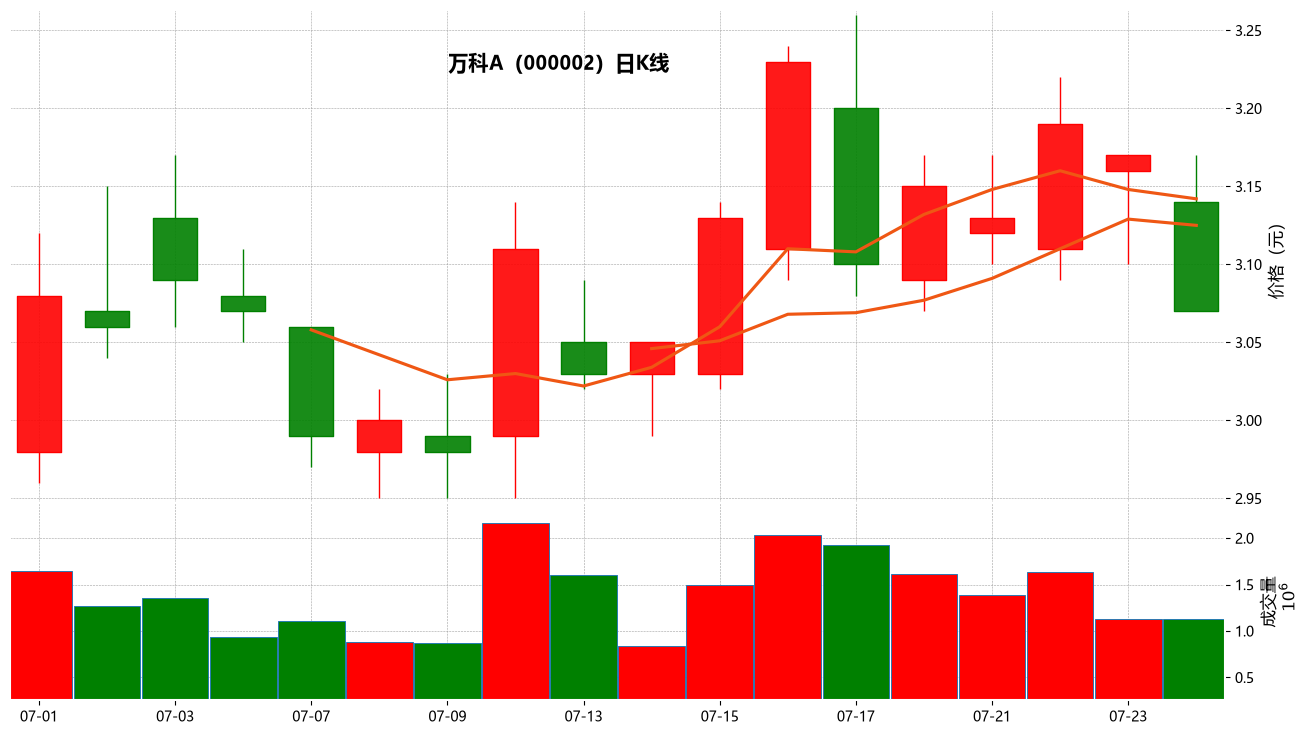

In [11]:
# 1. 复制数据，避免反复执行 Notebook 时修改原始 df
plot_df = df.copy()

# 2. 腾讯接口返回的是英文小写字段
plot_df = plot_df.rename(columns={
    "date": "Date",
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "volume": "Volume",
})

# 3. 日期必须成为 DatetimeIndex
plot_df["Date"] = pd.to_datetime(plot_df["Date"])
plot_df = plot_df.set_index("Date").sort_index()

# 4. 保证 OHLCV 是数值
price_columns = ["Open", "High", "Low", "Close", "Volume"]
plot_df[price_columns] = plot_df[price_columns].apply(
    pd.to_numeric,
    errors="coerce",
)

plot_df = plot_df.dropna(subset=["Open", "High", "Low", "Close"])

# 5. A股配色：红涨绿跌
market_colors = mpf.make_marketcolors(
    up="red",
    down="green",
    edge="inherit",
    wick="inherit",
    volume="inherit",
)

# 6. 创建支持中文的 mplfinance 样式
cn_style = mpf.make_mpf_style(
    base_mpf_style="charles",
    marketcolors=market_colors,
    rc={
        "font.family": "sans-serif",
        "font.sans-serif": ["Microsoft YaHei"],
        "axes.unicode_minus": False,
        "font.weight": "normal",
        "axes.titleweight": "normal",
        "axes.labelweight": "normal",
    },
)

# 7. 绗制K线
mpf.plot(
    plot_df,
    type="candle",
    volume=True,
    mav=(5, 10),
    title="万科A（000002）日K线",
    ylabel="价格（元）",
    ylabel_lower="成交量",
    style=cn_style,       # 不再写 style="charles"
    figsize=(14, 8),
    datetime_format="%m-%d",
    xrotation=0,
    tight_layout=True,
)

### A股实时行情

In [12]:
# 1. A股实时行情（新浪）
df = ak.stock_zh_a_spot()

print('A股实时行情:', df.shape)

df.head(5)

Please wait for a moment:   0%|          | 0/70 [00:00<?, ?it/s]

A股实时行情: (5536, 14)


,代码,名称,最新价,涨跌额,涨跌幅,买入,卖出,昨收,今开,最高,最低,成交量,成交额,时间戳
0,bj920000,安徽凤凰,14.97,0.58,4.031,14.93,14.96,14.39,14.50,15.16,14.20,2103469.0,31153748.0,11:34:58
1,bj920001,纬达光电,12.00,0.32,2.740,12.00,12.02,11.68,11.68,12.08,11.54,931107.0,11022129.0,11:34:58
2,bj920002,万达轴承,56.18,0.84,1.518,56.17,56.18,55.34,55.37,56.55,54.61,980434.0,54420509.0,11:34:58
3,bj920003,中诚咨询,16.85,0.15,0.898,16.85,16.86,16.70,16.67,16.86,16.66,132472.0,2218802.0,11:34:58
4,bj920005,鼎佳精密,25.37,0.54,2.175,25.24,25.39,24.83,24.72,25.46,24.60,210990.0,5323616.0,11:34:58


### 港股实时行情（新浪）

In [40]:
# 1. 港股实时行情（新浪）
df = ak.stock_hk_spot()

print('港股实时行情:', df.shape)

df.head(5)

  0%|          | 0/99 [00:00<?, ?it/s]

港股实时行情: (2806, 16)


,日期时间,代码,中文名称,英文名称,交易类型,最新价,涨跌额,涨跌幅,昨收,今开,最高,最低,成交量,成交额,买一,卖一
0,2026/08/04 16:08:28,00001,长和,CKH HOLDINGS,,74.000,1.000,1.36986,73.00,74.25,74.400,72.650,5970764,441471372,73.90000,74.000
1,2026/08/04 16:08:26,00002,中电控股,CLP HOLDINGS,,76.900,-0.650,-0.83817,77.55,77.60,77.800,76.600,3409539,262686196,76.85000,76.900
2,2026/08/04 16:08:26,00003,香港中华煤气,HK & CHINA GAS,,6.905,-0.055,-0.79023,6.96,7.00,7.005,6.885,17055041,117994486,6.90000,6.905
3,2026/08/04 16:08:20,00004,九龙仓集团,WHARF HOLDINGS,,19.440,-0.060,-0.30769,19.50,19.88,19.880,19.300,455482,8833904,19.43000,19.440
4,2026/08/04 16:08:26,00005,汇丰控股,HSBC HOLDINGS,,166.500,-1.700,-1.01070,168.20,168.40,169.700,164.000,27429003,4592038175,166.39999,166.500


In [13]:
df.tail(5)

,代码,名称,最新价,涨跌额,涨跌幅,买入,卖出,昨收,今开,最高,最低,成交量,成交额,时间戳
5531,sz301682,宏明电子,129.70,4.72,3.777,129.75,129.80,124.98,123.20,129.97,122.90,1816454.0,231251267.0,11:30:00
5532,sz301683,慧谷新材,103.19,1.59,1.565,103.03,103.19,101.60,101.00,103.40,100.23,558262.0,56997140.0,11:30:00
5533,sz301687,新广益,48.87,2.07,4.423,48.86,48.87,46.80,46.85,48.97,46.80,2843057.0,136448353.0,11:30:00
5534,sz301696,三瑞智能,106.30,2.91,2.815,106.29,106.43,103.39,102.50,106.51,102.13,2257816.0,236956443.0,11:30:00
5535,sz302132,中航成飞,58.08,0.09,0.155,58.08,58.09,57.99,57.99,58.32,57.56,3128705.0,181300253.0,11:30:00


### A股估值（东方财富）

In [15]:
# 1. A股估值指标（东方财富）
df = ak.stock_value_em(symbol='000002')

df = df.set_index('数据日期')

print('估值指标:', df.shape)

df.tail()

估值指标: (2083, 12)


,当日收盘价,当日涨跌幅,总市值,流通市值,总股本,流通股本,PE(TTM),PE(静),市净率,PEG值,市现率,市销率
数据日期,,,,,,,,,,,,
2026-07-29,3.28,4.126984,3.913273e+10,3.187155e+10,11930709471,9716935865,-0.443368,-0.441896,0.354030,0.003775,14.817286,0.174415
2026-07-30,3.33,1.524390,3.972926e+10,3.235740e+10,11930709471,9716935865,-0.450127,-0.448632,0.359426,0.003833,15.043159,0.177073
2026-07-31,3.34,0.300300,3.984857e+10,3.245457e+10,11930709471,9716935865,-0.451478,-0.449979,0.360506,0.003844,15.088334,0.177605
2026-08-03,3.36,0.598802,4.008718e+10,3.264890e+10,11930709471,9716935865,-0.454182,-0.452674,0.362664,0.003867,15.178683,0.178669
2026-08-04,3.26,-2.976190,3.889411e+10,3.167721e+10,11930709471,9716935865,-0.440664,-0.439201,0.351871,0.003752,14.726937,0.173351


---
## 3. `fundamentals`：公司与财务基本面

回答“这家公司经营得怎么样”。涵盖公司资料、财务三表、指标、股东与聚合预测。

**本教程收录的当前可用接口：23 个**

### 可用接口汇总

| 序号 | 子类 | 接口名称 | 接口函数 | 数据源 | 输入参数 |
| ---: | --- | --- | --- | --- | --- |
| 1 | `business_segments` | 主营介绍-同花顺 | `stock_zyjs_ths` | 同花顺 | symbol |
| 2 | `company_profile` | 个股公司概况-巨潮资讯 | `stock_profile_cninfo` | 巨潮 | symbol |
| 3 | `financial_indicators` | 财务报表-关键指标-新浪 | `stock_financial_abstract` | 新浪 | symbol |
| 4 | `financial_statements` | 财务报表-三大报表-新浪 | `stock_financial_report_sina` | 新浪 | stock, symbol |
| 5 | `financial_indicators` | 财务分析-财务指标-新浪 | `stock_financial_analysis_indicator` | 新浪 | symbol, start_year |
| 6 | `financial_indicators` | 财务指标-重要指标-同花顺；替换 stock_financial_abstract_ths 接口 | `stock_financial_abstract_new_ths` | 同花顺 | symbol, indicator |
| 7 | `financial_statements` | 财务指标-资产负债表-同花顺；替换 stock_financial_debt_ths 接口 | `stock_financial_debt_new_ths` | 同花顺 | symbol, indicator |
| 8 | `financial_statements` | 财务指标-利润表-同花顺；替换 stock_financial_benefit_ths 接口 | `stock_financial_benefit_new_ths` | 同花顺 | symbol, indicator |
| 9 | `financial_statements` | 财务指标-现金流量表-同花顺；替换 stock_financial_cash_ths 接口 | `stock_financial_cash_new_ths` | 同花顺 | symbol, indicator |
| 10 | `financial_indicators` | A股商誉市场概况-东方财富 | `stock_sy_profile_em` | 东方财富 | null |
| 11 | `forecasts` | 盈利预测-同花顺 | `stock_profit_forecast_ths` | 同花顺 | symbol, indicator |
| 12 | `forecasts` | 盈利预测-经济通 | `stock_hk_profit_forecast_et` | 经济通 | symbol, indicator |
| 13 | `shareholders` | 股东股本-流通股东-新浪 | `stock_circulate_stock_holder` | 新浪 | symbol |
| 14 | `shareholders` | 股东股本-基金持股-新浪 | `stock_fund_stock_holder` | 新浪 | symbol |
| 15 | `shareholders` | 机构持股-机构持股一览表-新浪 | `stock_institute_hold` | 新浪 | symbol |
| 16 | `shareholders` | 机构持股-机构持股详情-新浪 | `stock_institute_hold_detail` | 新浪/经济通 | stock, quarter |
| 17 | `shareholders` | 股东股本股东-主要股东-新浪 | `stock_main_stock_holder` | 新浪 | stock |
| 18 | `shareholders` | 股东持股分析-十大股东-东方财富 | `stock_gdfx_holding_analyse_em` | 东方财富 | date |
| 19 | `shareholders` | 股东持股分析-十大流通股东-东方财富 | `stock_gdfx_free_holding_analyse_em` | 东方财富 | date |
| 20 | `shareholders` | 股东持股变动统计-十大流通股东-东方财富 | `stock_gdfx_free_holding_change_em` | 东方财富 | date |
| 21 | `shareholders` | 股东持股明细-十大流通股东-东方财富 | `stock_gdfx_free_holding_detail_em` | 东方财富/经济通 | date |
| 22 | `shareholders` | 股东户数数据-东方财富 | `stock_zh_a_gdhs` | 未识别 | symbol |
| 23 | `shareholders` | 股东户数详情-东方财富 | `stock_zh_a_gdhs_detail_em` | 东方财富/经济通 | symbol |

### 个股公司概况-巨潮资讯

In [38]:
# 1. 个股公司概况-巨潮资讯
df = ak.stock_profile_cninfo(symbol="000002")

print('工商概况:', df.shape)

df.iloc[0]

工商概况: (1, 26)


公司名称                                           万科企业股份有限公司
英文名称                                China Vanke Co., Ltd.
曾用简称                                                 None
A股代码                                               000002
A股简称                                                万  科Ａ
B股代码                                                 None
B股简称                                                 None
H股代码                                                02202
H股简称                                                 万科企业
入选指数    ESG 300,国证Ａ指,沪深300,巨潮中盘,深成指R,深市精选,深证100,深证100R...
所属市场                                                深交所主板
所属行业                                                 房地产业
法人代表                                                  徐恩利
注册资金                                         1193070.9471
成立日期                                           1984-05-30
上市日期                                           1991-01-29
官方网站                                        www.vanke.com
电子邮箱          

### 关键财务指标（新浪）

In [42]:
# 1. 关键财务指标摘要（新浪）
df = ak.stock_financial_abstract(symbol='sz000002')

print('关键指标:', df.shape)

print(df['指标'].unique())

df.head(5)

关键指标: (80, 118)
<StringArray>
[             '归母净利润',              '营业总收入',               '营业成本',
                '净利润',              '扣非净利润',        '股东权益合计(净资产)',
                 '商誉',           '经营现金流量净额',             '基本每股收益',
              '每股净资产',              '每股现金流',        '净资产收益率(ROE)',
        '总资产报酬率(ROA)',                '毛利率',              '销售净利率',
              '期间费用率',              '资产负债率',             '稀释每股收益',
        '摊薄每股收益_最新股数',       '摊薄每股净资产_期末股数',       '调整每股净资产_期末股数',
         '每股净资产_最新股数',            '每股经营现金流',           '每股现金流量净额',
         '每股企业自由现金流量',         '每股股东自由现金流量',            '每股未分配利润',
            '每股资本公积金',            '每股盈余公积金',             '每股留存收益',
             '每股营业收入',            '每股营业总收入',            '每股息税前利润',
           '摊薄净资产收益率',          '净资产收益率_平均',  '净资产收益率_平均_扣除非经常损益',
   '摊薄净资产收益率_扣除非经常损益',             '息税前利润率',             '总资产报酬率',
             '总资本回报率',            '投入资本回报率',      '息前税后总资产报酬率_平均',
            '成本费用利润率',          

,选项,指标,20260331,20251231,20250930,20250630,20250331,20241231,20240930,20240630,...,19970630,19961231,19960630,19951231,19950630,19941231,19940630,19931231,19930630,19921231
0,常用指标,归母净利润,-5.952156e+09,-8.855647e+10,-2.801584e+10,-1.194657e+10,-6.246209e+09,-4.947843e+10,-1.794330e+10,-9.852500e+09,...,6.567690e+07,1.496633e+08,5.360104e+07,1.474524e+08,6.417847e+07,1.733679e+08,7.580607e+07,1.534053e+08,8.181326e+07,7.002406e+07
1,常用指标,营业总收入,2.892789e+10,2.334328e+11,1.613884e+11,1.053233e+11,3.799465e+10,3.431764e+11,2.198948e+11,1.427788e+11,...,8.294705e+08,1.189214e+09,5.121157e+08,1.515465e+09,6.538518e+08,1.249663e+09,3.700227e+08,1.091759e+09,4.674537e+08,6.613562e+08
2,常用指标,营业成本,3.189235e+10,2.424212e+11,1.676000e+11,1.080665e+11,4.224814e+10,3.498502e+11,2.246142e+11,1.455577e+11,...,NaN,1.081474e+09,NaN,1.361898e+09,NaN,1.115838e+09,NaN,1.055529e+09,NaN,6.335392e+08
3,常用指标,净利润,-6.091605e+09,-9.181009e+10,-2.823666e+10,-1.086498e+10,-6.415199e+09,-4.870393e+10,-1.639811e+10,-8.520745e+09,...,7.219691e+07,1.541751e+08,5.360104e+07,1.668964e+08,6.314928e+07,1.759682e+08,7.707206e+07,1.609206e+08,8.210057e+07,7.297580e+07
4,常用指标,扣非净利润,-5.334174e+09,-8.591736e+10,-2.648614e+10,-1.159102e+10,-6.038700e+09,-4.539372e+10,-1.446760e+10,-7.613049e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 资产负债表（同花顺）

In [41]:
# 1. 同花顺资产负债表
df = ak.stock_financial_debt_new_ths(symbol="000002", indicator="按年度")

print('资产负债表:', df.shape)

print(df['report_name'].unique())
print(df['quarter_name'].unique())
print(df['metric_name'].unique())

df.head(5)

资产负债表: (4165, 10)
<StringArray>
['2025年报', '2024年报', '2023年报', '2022年报', '2021年报', '2020年报', '2019年报',
 '2018年报', '2017年报', '2016年报', '2015年报', '2014年报', '2013年报', '2012年报',
 '2011年报', '2010年报', '2009年报', '2008年报', '2007年报', '2006年报', '2005年报',
 '2004年报', '2003年报', '2002年报', '2001年报', '2000年报', '1999年报', '1998年报',
 '1997年报', '1996年报', '1995年报', '1994年报', '1993年报', '1992年报', '1991年报']
Length: 35, dtype: str
<StringArray>
['2025四季度', '2024四季度', '2023四季度', '2022四季度', '2021四季度', '2020四季度', '2019四季度',
 '2018四季度', '2017四季度', '2016四季度', '2015四季度', '2014四季度', '2013四季度', '2012四季度',
 '2011四季度', '2010四季度', '2009四季度', '2008四季度', '2007四季度', '2006四季度', '2005四季度',
 '2004四季度', '2003四季度', '2002四季度', '2001四季度', '2000四季度', '1999四季度', '1998四季度',
 '1997四季度', '1996四季度', '1995四季度', '1994四季度', '1993四季度', '1992四季度', '1991四季度']
Length: 35, dtype: str
<StringArray>
[                          'treasury_stock',
             'productive_biological_assets',
                        'deferred_tax_debt',
              

,report_date,report_name,report_period,quarter_name,metric_name,value,single,yoy,mom,single_yoy
0,2025-12-31,2025年报,2025-4,2025四季度,treasury_stock,,,,,
1,2025-12-31,2025年报,2025-4,2025四季度,productive_biological_assets,216117733.5300,,-0.14878916,,
2,2025-12-31,2025年报,2025-4,2025四季度,deferred_tax_debt,4697757860.4900,,-0.12170587,,
3,2025-12-31,2025年报,2025-4,2025四季度,other_payable_total,133735785207.2500,,-0.12199084,,
4,2025-12-31,2025年报,2025-4,2025四季度,equity,11930709471.0000,,0.00000000,,


### 流通股东（新浪）

In [44]:
# 1. 流通股东（新浪）
df = ak.stock_circulate_stock_holder(symbol='sz000002')

print('流通股东:', df.shape)

df.head(5)

  0%|          | 0/90 [00:00<?, ?it/s]

流通股东: (895, 7)


,截止日期,公告日期,编号,股东名称,持股数量,占流通股比例,股本性质
0,2026-03-31,2026-04-30,1,深铁集团,3242810791,27.197,国有股
1,2026-03-31,2026-04-30,2,HKSCC NOMINEES LIMITED,2206363864,18.504,境外法人股
2,2026-03-31,2026-04-30,3,中央汇金资产管理有限责任公司,185478200,1.556,国有股
3,2026-03-31,2026-04-30,4,香港中央结算有限公司,147049855,1.233,境外法人股
4,2026-03-31,2026-04-30,5,中国工商银行股份有限公司-南方中证全指房地产交易型开放式指数证券投资基金,81997589,0.688,境内法人股


---
## 4. `corporate_actions`：公司行为与股本事件

回答“持有人的权益发生了什么”。涵盖发行、分红、回购、解禁、质押和股本变化。

**本教程收录的当前可用接口：37 个**

### 可用接口汇总

| 序号 | 子类 | 接口名称 | 接口函数 | 数据源 | 输入参数 |
| ---: | --- | --- | --- | --- | --- |
| 1 | `capital_change` | 股东大会-东方财富 | `stock_gddh_em` | 东方财富 | null |
| 2 | `capital_change` | 股东高管持股-东方财富 | `stock_ggcg_em` | 东方财富 | symbol |
| 3 | `capital_change` | 董监高及相关人员持股变动明细-东方财富 | `stock_hold_management_detail_em` | 东方财富/经济通 | null |
| 4 | `capital_change` | 股东股本结构-东方财富 | `stock_zh_a_gbjg_em` | 东方财富/北交所 | symbol |
| 5 | `capital_change` | 股东股本-股本变动-巨潮资讯 | `stock_hold_change_cninfo` | 巨潮 | symbol |
| 6 | `capital_change` | 股东股本-高管持股变动明细-巨潮资讯 | `stock_hold_management_detail_cninfo` | 巨潮/经济通 | symbol |
| 7 | `dividend` | 历史分红-巨潮资讯 | `stock_dividend_cninfo` | 巨潮 | symbol |
| 8 | `dividend` | 分红配送详情-东方财富 | `stock_fhps_detail_em` | 东方财富/经济通 | symbol |
| 9 | `dividend` | 分红配送详情-同花顺 | `stock_fhps_detail_ths` | 同花顺/经济通 | symbol |
| 10 | `dividend` | 历史分红-新浪 | `stock_history_dividend` | 新浪 | null |
| 11 | `dividend` | 历史分红详情-新浪 | `stock_history_dividend_detail` | 新浪/经济通 | symbol, indicator, date |
| 12 | `dividend` | 分红派息-百度 | `news_trade_notify_dividend_baidu` | 百度 | date, cookie |
| 13 | `dividend` | 港股分红派息-东方财富 | `stock_hk_dividend_payout_em` | 东方财富 | symbol |
| 14 | `issuance` | 新股申购-首发申报企业信息-东方财富 | `stock_ipo_declare_em` | 东方财富 | null |
| 15 | `issuance` | 新股申购-打新收益率-东方财富 | `stock_dxsyl_em` | 东方财富 | null |
| 16 | `issuance` | 新股申购-上会信息-东方财富 | `stock_ipo_review_em` | 东方财富 | null |
| 17 | `issuance` | 新股申购-IPO辅导信息-东方财富 | `stock_ipo_tutor_em` | 东方财富 | null |
| 18 | `issuance` | 新股申购-IPO审核信息-全部-东方财富 | `stock_register_all_em` | 东方财富 | null |
| 19 | `issuance` | 新股申购-IPO审核信息-北交所-东方财富 | `stock_register_bj` | 北交所 | null |
| 20 | `issuance` | 新股申购-IPO审核信息-创业板-东方财富 | `stock_register_cyb` | 未识别 | null |
| 21 | `issuance` | 新股申购-IPO审核信息-科创板-东方财富 | `stock_register_kcb` | 未识别 | null |
| 22 | `issuance` | 新股申购-IPO审核信息-上海主板-东方财富 | `stock_register_sh` | 未识别 | null |
| 23 | `issuance` | 新股申购-IPO审核信息-深圳主板-东方财富 | `stock_register_sz` | 未识别 | null |
| 24 | `issuance` | 新股申购-注册制审核-达标企业-东方财富 | `stock_register_db` | 未识别 | null |
| 25 | `issuance` | 新股申购-全部增发-东方财富 | `stock_qbzf_em` | 东方财富 | null |
| 26 | `issuance` | 新股申购与中签-东方财富 | `stock_xgsglb_em` | 东方财富 | symbol |
| 27 | `issuance` | 新股上市首日-同花顺 | `stock_xgsr_ths` | 同花顺 | null |
| 28 | `issuance` | 港股新股申购与中签-同花顺 | `stock_ipo_hk_ths` | 同花顺 | null |
| 29 | `issuance` | 新股发行-新浪 | `stock_ipo_info` | 新浪 | stock |
| 30 | `issuance` | 新股发行-巨潮资讯 | `stock_new_ipo_cninfo` | 巨潮 | null |
| 31 | `issuance` | 个股上市相关-巨潮资讯 | `stock_ipo_summary_cninfo` | 巨潮 | symbol |
| 32 | `pledge` | 股权质押-巨潮资讯 | `stock_cg_equity_mortgage_cninfo` | 巨潮 | date |
| 33 | `pledge` | 股权质押-重要股东股权质押明细-东方财富 | `stock_gpzy_pledge_ratio_detail_em` | 东方财富/经济通 | null |
| 34 | `pledge` | 股权质押-质押市场概况-东方财富 | `stock_gpzy_profile_em` | 东方财富 | null |
| 35 | `repurchase` | 股票回购-东方财富 | `stock_repurchase_em` | 东方财富 | null |
| 36 | `unlock` | 限售股解禁概览-东方财富 | `stock_restricted_release_summary_em` | 东方财富 | symbol, start_date, end_date |
| 37 | `unlock` | 限售股解禁详情-东方财富 | `stock_restricted_release_detail_em` | 东方财富 | start_date, end_date |

### 分红配送

In [53]:
# 1. 分红配送详情
df_div = ak.stock_fhps_detail_em(symbol='600000')

print('分红配送:', df_div.shape)

df_div.tail()

  0%|          | 0/1 [00:00<?, ?it/s]

分红配送: (26, 19)


,报告期,业绩披露日期,送转股份-送转总比例,送转股份-送股比例,送转股份-转股比例,现金分红-现金分红比例,现金分红-现金分红比例描述,现金分红-股息率,每股收益,每股净资产,每股公积金,每股未分配利润,净利润同比增长,总股本,预案公告日,股权登记日,除权除息日,方案进度,最新公告日期
21,2021-12-31,2022-04-28,NaN,NaN,NaN,4.10,"10派4.10元(含税,扣税后3.69元)",0.052632,1.62,19.08,2.785568,6.578632,-9.124732,29352173289,2022-04-28,2022-07-20,2022-07-21,实施分配,2022-07-13
22,2022-12-31,2023-04-19,NaN,NaN,NaN,3.20,"10派3.20元(含税,扣税后2.88元)",0.043127,1.56,20.03,2.785568,6.923549,-3.456408,29352175642,2023-04-19,2023-07-20,2023-07-21,实施分配,2023-07-13
23,2023-12-31,2024-04-30,NaN,NaN,NaN,3.21,"10派3.21元(含税,扣税后2.889元)",0.035509,1.07,20.95,2.785568,7.097745,-28.275781,29352177375,2024-04-30,2024-07-17,2024-07-18,实施分配,2024-07-11
24,2024-12-31,2025-03-29,NaN,NaN,NaN,4.10,"10派4.10元(含税,扣税后3.69元)",0.029433,1.36,22.36,2.790985,7.849584,23.309356,30267679579,2025-03-29,2025-07-15,2025-07-16,实施分配,2025-07-10
25,2025-12-31,2026-03-31,NaN,NaN,NaN,4.20,"10派4.20元(含税,扣税后3.78元)",0.045113,1.52,22.13,4.037140,7.535069,10.517710,33305838300,2026-03-31,2026-07-15,2026-07-16,实施分配,2026-07-10


### IPO 审核

In [49]:
# 1. 新股上会信息
df = ak.stock_ipo_review_em()

print('新股上会:', df.shape)

df.head(3)

  0%|          | 0/11 [00:00<?, ?it/s]

新股上会: (5267, 13)


,序号,企业名称,股票简称,股票代码,上市板块,上会日期,审核状态,发审委委员,主承销商,发行数量(股),拟融资额(元),公告日期,上市日期
0,1,重庆宇隆光电科技股份有限公司,宇隆科技,A25276,深交所创业板,2026-08-06,未上会,"王靓,王蕾,孙培贤,李阳,李岚",中信证券,129100845,1.000000e+09,2026-07-01,NaT
1,2,德阳天元重工股份有限公司,天元重工,A25226,北交所,2026-07-31,上会通过,"朱嘉敏,王澎涛,李文娟,李中全,张华",第一创业证券,57100000,2.912687e+04,2025-12-30,NaT
2,3,苏州猎奇智能设备股份有限公司,猎奇智能,A25297,深交所创业板,2026-07-31,上会通过,"王灵钰,沈哲,张勇,贾蕊,喻婕",国泰海通证券,13750000,9.134139e+08,2026-07-14,NaT


In [50]:
# 2. IPO审核信息-全部
df_reg = ak.stock_register_all_em()

print('IPO审核:', df_reg.shape)

df_reg.head()

  0%|          | 0/9 [00:00<?, ?it/s]

IPO审核: (4398, 12)


,序号,企业名称,最新状态,注册地,行业,保荐机构,律师事务所,会计师事务所,更新日期,受理日期,拟上市地点,招股说明书
0,1,杭州玄机科技股份有限公司,已问询,浙江省 杭州市,软件和信息技术服务业,中信建投证券股份有限公司,北京市君合律师事务所,立信会计师事务所(特殊普通合伙),2026-08-03,2026-04-22,北交所,https://pdf.dfcfw.com/pdf/H2_AN202604221821449...
1,2,沈鼓集团股份有限公司,注册生效,辽宁,通用设备制造业,中国国际金融股份有限公司,北京市嘉源律师事务所,天职国际会计师事务所(特殊普通合伙),2026-08-03,2025-12-25,沪主板,https://pdf.dfcfw.com/pdf/H2_AN202606041823250...
2,3,浙江欧诺机械科技股份有限公司,已问询,浙江,专用设备制造业,光大证券股份有限公司,北京市天元律师事务所,立信会计师事务所(特殊普通合伙),2026-08-03,2026-05-08,深主板,https://pdf.dfcfw.com/pdf/H2_AN202608031827587...
3,4,北方实验室(沈阳)股份有限公司,已问询,辽宁省 沈阳市,软件和信息技术服务业,开源证券股份有限公司,北京市立方律师事务所,容诚会计师事务所(特殊普通合伙),2026-08-03,2025-06-23,北交所,https://pdf.dfcfw.com/pdf/H2_AN202506231696212...
4,5,苏州猎奇智能设备股份有限公司,提交注册,江苏,专用设备制造业,国泰海通证券股份有限公司,江苏世纪同仁律师事务所,容诚会计师事务所(特殊普通合伙),2026-08-02,2025-12-26,创业板,https://pdf.dfcfw.com/pdf/H2_AN202608021827565...


### 增发/回购

In [51]:
# === 增发/回购 + 解禁 + 分红 ===
# 1. 股票回购数据
df_repurchase = ak.stock_repurchase_em()

print('股票回购:', df_repurchase.shape)

df_repurchase.head()

股票回购: (5446, 18)


,序号,股票代码,股票简称,最新价,计划回购价格区间,计划回购数量区间-下限,计划回购数量区间-上限,占公告前一日总股本比例-下限,占公告前一日总股本比例-上限,计划回购金额区间-下限,计划回购金额区间-上限,回购起始时间,实施进度,已回购股份价格区间-下限,已回购股份价格区间-上限,已回购股份数量,已回购金额,最新公告日期
0,1,688312,燕麦科技,43.20,70.00,142857.0,285714.0,0.097370,0.194741,10000000.0,20000000.0,2026-08-04,董事会预案,NaN,NaN,NaN,NaN,2026-08-05
1,2,688251,井松智能,20.80,33.00,454545.0,606060.0,0.451823,0.602431,15000000.0,20000000.0,2026-08-04,董事会预案,NaN,NaN,NaN,NaN,2026-08-05
2,3,301330,熵基科技,24.19,36.07,831717.0,1663432.0,0.353393,0.706786,30000000.0,60000000.0,2026-08-04,董事会预案,NaN,NaN,NaN,NaN,2026-08-05
3,4,300891,惠云钛业,6.82,9.50,2105263.0,3157894.0,0.526305,0.789457,20000000.0,30000000.0,2026-08-04,董事会预案,NaN,NaN,NaN,NaN,2026-08-05
4,5,000783,长江证券,8.83,14.01,7137759.0,14275517.0,0.129072,0.258143,100000000.0,200000000.0,2026-08-04,董事会预案,NaN,NaN,NaN,NaN,2026-08-05


### 限售股解禁

In [52]:
# 1. 限售股解禁详情
df_release = ak.stock_restricted_release_detail_em(start_date='20260101', end_date='20260630')

print('限售解禁:', df_release.shape)

df_release.tail()

限售解禁: (736, 12)


,序号,股票代码,股票简称,解禁时间,限售股类型,解禁数量,实际解禁数量,实际解禁市值,占解禁前流通市值比例,解禁前一交易日收盘价,解禁前20日涨跌幅,解禁后20日涨跌幅
731,732,301105,鸿铭股份,2026-06-30,"首发原股东限售股份,追加承诺限售股份上市流通",33562503.0,3375001.0,1.450575e+08,0.170347,42.98,-18.829707,-2.383864
732,733,001369,双欣材料,2026-06-30,首发机构配售股份,6424045.0,6424045.0,8.685309e+07,0.030966,13.52,-7.813571,-6.319703
733,734,301448,开创电气,2026-06-30,首发原股东限售股份,56160000.0,22600500.0,1.025611e+09,0.318842,45.38,33.915575,-9.717391
734,735,600789,鲁抗医药,2026-06-30,定向增发机构配售股份,111628565.0,111628565.0,7.601905e+08,0.110491,6.81,-5.837563,-0.386407
735,736,688582,芯动联科,2026-06-30,首发原股东限售股份,151520000.0,151520000.0,9.848800e+09,0.377160,65.00,23.634497,-37.419033


---
## 5. `sector`：行业、概念与市场结构

回答“公司处于哪个行业，行业整体表现如何”。涵盖行业/概念分类、行情、估值与中观指标。

**本教程收录的当前可用接口：11 个**

### 可用接口汇总

| 序号 | 子类 | 接口名称 | 接口函数 | 数据源 | 输入参数 |
| ---: | --- | --- | --- | --- | --- |
| 1 | `history` | 申万行业分类 | `stock_industry_clf_hist_sw` | 未识别 | null |
| 2 | `industry_metrics` | 上市公司质押比例 | `stock_gpzy_industry_data_em` | 东方财富 | null |
| 3 | `quotes` | 同花顺行业一览表 | `stock_board_industry_summary_ths` | 同花顺 | null |
| 4 | `quotes` | 概念板块-指数日频率数据-同花顺 | `stock_board_concept_index_ths` | 同花顺 | symbol, start_date, end_date |
| 5 | `quotes` | 行业板块-指数日频率数据-同花顺 | `stock_board_industry_index_ths` | 同花顺 | symbol, start_date, end_date |
| 6 | `valuation` | 港股-行业对比-成长性对比 | `stock_hk_growth_comparison_em` | 东方财富 | symbol |
| 7 | `valuation` | 港股-行业对比-规模对比 | `stock_hk_scale_comparison_em` | 东方财富 | symbol |
| 8 | `valuation` | 港股-行业对比-估值对比 | `stock_hk_valuation_comparison_em` | 东方财富 | symbol |
| 9 | `valuation` | 同行比较-成长性比较 | `stock_zh_growth_comparison_em` | 东方财富 | symbol |
| 10 | `valuation` | 同行比较-公司规模 | `stock_zh_scale_comparison_em` | 东方财富 | symbol |
| 11 | `valuation` | 行业分析-行业市盈率 | `stock_industry_pe_ratio_cninfo` | 巨潮 | symbol, date |

### 行业板块（同花顺）

直接调用 AKShare 接口获取行业板块列表；这里只观察原始返回，不进行再封装。

In [54]:
# 1.行业板块概览（同花顺）
stock_board_industry_summary_df = ak.stock_board_industry_summary_ths()
display(stock_board_industry_summary_df.head())

  0%|          | 0/2 [00:00<?, ?it/s]

,序号,板块,涨跌幅,总成交量,总成交额,净流入,上涨家数,下跌家数,均价,领涨股,领涨股-最新价,领涨股-涨跌幅
0,1,电子化学品,8.02,1019.57,468.05,26.16,43,0,45.91,中巨芯,23.21,20.01
1,2,贵金属,7.16,1142.03,308.61,55.82,14,0,27.02,四川黄金,43.27,9.99
2,3,半导体,6.44,4125.88,3378.11,115.04,182,1,81.88,有研硅,33.64,20.01
3,4,元件,6.10,2074.33,1239.88,49.38,63,0,59.77,胜宏科技,240.58,19.22
4,5,小金属,6.04,1013.56,359.56,-6.75,29,0,35.48,浩通科技,21.49,19.99


In [57]:
# 2.行业板块指数（同花顺）
df = ak.stock_board_industry_index_ths(symbol="半导体", start_date="20260701", end_date="20260718")
display(df.head())

  0%|          | 0/1 [00:00<?, ?it/s]

,日期,开盘价,最高价,最低价,收盘价,成交量,成交额
0,2026-07-01,22874.349,23765.394,22452.958,22725.017,6475937300,6.762902e+11
1,2026-07-02,21744.739,22636.240,21228.115,21472.776,5720043700,5.817642e+11
2,2026-07-03,21335.266,21653.357,20708.729,20930.544,5136457800,5.222825e+11
3,2026-07-06,21227.880,21347.505,20031.036,20846.677,4913813800,5.151694e+11
4,2026-07-07,20582.910,21352.172,20398.093,20963.083,4644033200,4.581205e+11


---
## 6. `flows_events`：资金、交易行为与市场事件

回答“资金和交易行为发生了什么”。涵盖资金流、两融、北向、龙虎榜、大宗、涨停与情绪。

**本教程收录的当前可用接口：65 个**

### 可用接口汇总

| 序号 | 子类 | 接口名称 | 接口函数 | 数据源 | 输入参数 |
| ---: | --- | --- | --- | --- | --- |
| 1 | `block_trade` | 大宗交易-活跃 A 股统计 | `stock_dzjy_hygtj` | 未识别 | symbol |
| 2 | `block_trade` | 大宗交易-活跃营业部统计 | `stock_dzjy_hyyybtj` | 未识别 | symbol |
| 3 | `block_trade` | 大宗交易-每日明细 | `stock_dzjy_mrmx` | 未识别 | symbol, start_date, end_date |
| 4 | `block_trade` | 大宗交易-每日统计 | `stock_dzjy_mrtj` | 未识别 | start_date, end_date |
| 5 | `block_trade` | 大宗交易-市场统计 | `stock_dzjy_sctj` | 未识别 | null |
| 6 | `block_trade` | 大宗交易-营业部排行 | `stock_dzjy_yybph` | 未识别 | symbol |
| 7 | `fund_flow` | 资金流向-大单追踪 | `stock_fund_flow_big_deal` | 同花顺 | null |
| 8 | `limit_up` | 赚钱效应分析数据 | `stock_market_activity_legu` | 乐估乐股/经济通 | null |
| 9 | `limit_up` | 涨停板行情-跌停股池 | `stock_zt_pool_dtgc_em` | 东方财富 | date |
| 10 | `limit_up` | 涨停板行情-涨停股池 | `stock_zt_pool_em` | 东方财富 | date |
| 11 | `limit_up` | 涨停板行情-昨日涨停股池 | `stock_zt_pool_previous_em` | 东方财富 | date |
| 12 | `limit_up` | 涨停板行情-强势股池 | `stock_zt_pool_strong_em` | 东方财富 | date |
| 13 | `limit_up` | 涨停板行情-次新股池 | `stock_zt_pool_sub_new_em` | 东方财富 | date |
| 14 | `limit_up` | 涨停板行情-炸板股池 | `stock_zt_pool_zbgc_em` | 东方财富 | date |
| 15 | `margin` | 融资融券账户统计-两融账户信息 | `stock_margin_account_info` | 未识别 | null |
| 16 | `margin` | 北交所-融资融券汇总数据 | `stock_margin_bse` | 北交所 | date |
| 17 | `margin` | 北交所-融资融券交易明细数据 | `stock_margin_detail_bse` | 北交所/经济通 | date |
| 18 | `margin` | 上交所-融资融券明细数据 | `stock_margin_detail_sse` | 上交所/经济通 | date |
| 19 | `margin` | 深交所-融资融券交易明细数据 | `stock_margin_detail_szse` | 深交所/经济通 | date |
| 20 | `margin` | 上交所-融资融券汇总数据 | `stock_margin_sse` | 上交所 | start_date, end_date |
| 21 | `margin` | 深交所-融资融券汇总数据 | `stock_margin_szse` | 深交所 | date |
| 22 | `margin` | 北交所-融资融券标的证券信息 | `stock_margin_underlying_info_bse` | 北交所 | date |
| 23 | `margin` | 深交所-融资融券标的证券信息 | `stock_margin_underlying_info_szse` | 深交所 | date |
| 24 | `northbound` | 沪港通-港股通资金流向 | `stock_hsgt_fund_flow_summary_em` | 东方财富 | null |
| 25 | `northbound` | 沪港通-市场概括-分时数据 | `stock_hsgt_fund_min_em` | 东方财富 | symbol |
| 26 | `northbound` | 沪港通-历史数据 | `stock_hsgt_hist_em` | 东方财富 | symbol |
| 27 | `northbound` | 沪港通-港股通信息披露-参考汇率 | `stock_sgt_reference_exchange_rate_sse` | 上交所 | null |
| 28 | `northbound` | 沪港通-港股通信息披露-结算汇兑 | `stock_sgt_settlement_exchange_rate_sse` | 上交所/经济通 | null |
| 29 | `sentiment` | 股票账户统计 | `stock_account_statistics_em` | 东方财富 | null |
| 30 | `sentiment` | 市场热度-市场参与意愿 | `stock_comment_detail_scrd_desire_em` | 东方财富/经济通 | symbol |
| 31 | `sentiment` | 市场热度-用户关注指数 | `stock_comment_detail_scrd_focus_em` | 东方财富/经济通 | symbol |
| 32 | `sentiment` | 综合评价-历史评分 | `stock_comment_detail_zhpj_lspf_em` | 东方财富/经济通 | symbol |
| 33 | `sentiment` | 主力控盘-机构参与度 | `stock_comment_detail_zlkp_jgcyd_em` | 东方财富/经济通 | symbol |
| 34 | `sentiment` | 个股人气榜-股票热度-东方财富 | `stock_hot_rank_em` | 东方财富 | null |
| 35 | `sentiment` | 个股人气榜-最新排名-东方财富 | `stock_hot_rank_latest_em` | 东方财富 | symbol |
| 36 | `sentiment` | 港股-个股人气榜-股票热度-东方财富 | `stock_hk_hot_rank_em` | 东方财富 | null |
| 37 | `sentiment` | 港股-个股人气榜-最新排名-东方财富 | `stock_hk_hot_rank_latest_em` | 东方财富 | symbol |
| 38 | `sentiment` | 个股人气榜-飙升榜-东方财富 | `stock_hot_up_em` | 东方财富 | null |
| 39 | `sentiment` | 热度排行榜-交易排行榜-雪球 | `stock_hot_deal_xq` | 雪球 | symbol |
| 40 | `sentiment` | 技术选股-持续放量-同花顺 | `stock_rank_cxfl_ths` | 同花顺/财新 | null |
| 41 | `sentiment` | 技术选股-持续缩量-同花顺 | `stock_rank_cxsl_ths` | 同花顺/财新 | null |
| 42 | `sentiment` | 技术选股-量价齐跌-同花顺 | `stock_rank_ljqd_ths` | 同花顺 | null |
| 43 | `sentiment` | 技术选股-量价齐升-同花顺 | `stock_rank_ljqs_ths` | 同花顺 | null |
| 44 | `sentiment` | 技术选股-连续上涨-同花顺 | `stock_rank_lxsz_ths` | 同花顺 | null |
| 45 | `sentiment` | 技术选股-连续下跌-同花顺 | `stock_rank_lxxd_ths` | 同花顺 | null |
| 46 | `sentiment` | 技术选股-险资举牌-同花顺 | `stock_rank_xzjp_ths` | 同花顺 | null |
| 47 | `sentiment` | 热搜股票-百度 | `stock_hot_search_baidu` | 百度 | symbol, date, time |
| 48 | `sentiment` | 股评投票-百度 | `stock_zh_vote_baidu` | 百度 | symbol, indicator |
| 49 | `unusual_trade` | 当日板块异动详情 | `stock_board_change_em` | 东方财富 | null |
| 50 | `unusual_trade` | 盘口异动数据 | `stock_changes_em` | 东方财富 | symbol |
| 51 | `unusual_trade` | 沪深股市-内部交易 | `stock_inner_trade_xq` | 雪球 | null |
| 52 | `unusual_trade` | 龙虎榜-营业部排行-资金实力最强 | `stock_lh_yyb_capital` | 未识别 | null |
| 53 | `unusual_trade` | 龙虎榜-营业部排行-抱团操作实力 | `stock_lh_yyb_control` | 未识别 | null |
| 54 | `unusual_trade` | 龙虎榜-营业部排行-上榜次数最多 | `stock_lh_yyb_most` | 未识别 | null |
| 55 | `unusual_trade` | 龙虎榜-每日详情-新浪 | `stock_lhb_detail_daily_sina` | 新浪/经济通 | date |
| 56 | `unusual_trade` | 龙虎榜-机构席位成交明细-新浪 | `stock_lhb_jgmx_sina` | 新浪 | null |
| 57 | `unusual_trade` | 龙虎榜-营业上榜统计-新浪 | `stock_lhb_yytj_sina` | 新浪 | symbol |
| 58 | `unusual_trade` | 龙虎榜单-龙虎榜详情-东方财富 | `stock_lhb_detail_em` | 东方财富/经济通 | start_date, end_date |
| 59 | `unusual_trade` | 龙虎榜单-每日活跃营业部-东方财富 | `stock_lhb_hyyyb_em` | 东方财富 | start_date, end_date |
| 60 | `unusual_trade` | 龙虎榜-机构买卖每日统计-东方财富 | `stock_lhb_jgmmtj_em` | 东方财富 | start_date, end_date |
| 61 | `unusual_trade` | 龙虎榜单-机构席位追踪-东方财富 | `stock_lhb_jgstatistic_em` | 东方财富 | symbol |
| 62 | `unusual_trade` | 龙虎榜单-个股上榜统计-东方财富 | `stock_lhb_stock_statistic_em` | 东方财富 | symbol |
| 63 | `unusual_trade` | 龙虎榜单-营业部统计-东方财富网 | `stock_lhb_traderstatistic_em` | 东方财富 | symbol |
| 64 | `unusual_trade` | 龙虎榜单-营业部排行-东方财富网 | `stock_lhb_yybph_em` | 东方财富 | symbol |
| 65 | `unusual_trade` | 停复牌信息-东方财富 | `stock_tfp_em` | 东方财富 | date |

### 市场参与与涨跌停

In [58]:
# 5. 股票账户统计月度
df = ak.stock_market_activity_legu()

df

,item,value
0,上涨,3105.0
1,涨停,122.0
2,真实涨停,113.0
3,st st*涨停,1.0
4,下跌,1942.0
5,跌停,2.0
6,真实跌停,0.0
7,st st*跌停,1.0
8,平盘,152.0
9,停牌,5.0


### 龙虎榜明细

In [59]:
# 1. 龙虎榜明细（东财）
df_lhb = ak.stock_lhb_detail_em(start_date='20260704', end_date='20260708')

print('龙虎榜明细:', df_lhb.shape)

df_lhb.head()

  0%|          | 0/1 [00:00<?, ?it/s]

龙虎榜明细: (285, 21)


,序号,代码,名称,上榜日,解读,收盘价,涨跌幅,龙虎榜净买额,龙虎榜买入额,龙虎榜卖出额,...,市场总成交额,净买额占总成交比,成交额占总成交比,换手率,流通市值,上榜原因,上榜后1日,上榜后2日,上榜后5日,上榜后10日
0,1,000004,国华退,2026-07-08,普通席位卖出，成功率47.87%,0.38,-5.0000,2.361020e+05,8.973750e+05,6.612730e+05,...,1799704,13.118935,86.605797,3.7205,4.798985e+07,退市整理期,10.526316,21.052632,NaN,NaN
1,2,000004,国华退,2026-07-07,卖一主卖，成功率58.95%,0.40,-2.4390,2.892952e+05,1.860432e+06,1.571137e+06,...,3102426,9.324807,110.609221,6.1298,5.051563e+07,退市整理期,-5.000000,5.000000,NaN,NaN
2,3,000004,国华退,2026-07-06,主力做T，成功率61.95%,0.41,-8.8889,-1.807067e+05,1.495068e+06,1.675774e+06,...,3103588,-5.822509,102.166980,5.5397,5.177852e+07,退市整理期,-2.439024,-7.317073,24.390244,NaN
3,4,000007,全新好,2026-07-07,5家机构卖出，成功率16.67%,11.59,-10.0155,-2.702227e+07,3.465810e+07,6.168037e+07,...,203058414,-13.307633,47.443723,4.8479,4.015333e+09,日振幅值达到15%的前5只证券,-3.364970,-6.384815,-12.165660,-23.554789
4,5,000066,中国长城,2026-07-06,1家机构买入，成功率46.95%,18.82,9.9942,6.270860e+08,9.313754e+08,3.042893e+08,...,3729009536,16.816424,33.136538,6.3972,6.070485e+10,日涨幅偏离值达到7%的前5只证券,-1.275239,2.603613,-4.091392,-23.485654


In [60]:
# 2. 龙虎榜机构买卖统计
df_jg = ak.stock_lhb_jgmmtj_em(start_date='20260704', end_date='20260708')

print('机构买卖统计:', df_jg.shape)

df_jg.head()

  0%|          | 0/1 [00:00<?, ?it/s]

机构买卖统计: (167, 16)


,序号,代码,名称,收盘价,涨跌幅,买方机构数,卖方机构数,机构买入总额,机构卖出总额,机构买入净额,市场总成交额,机构净买额占总成交额比,换手率,流通市值,上榜原因,上榜日期
0,1,001399,惠科股份,34.78,-8.7618,3,4,1.182645e+09,8.437497e+08,3.388948e+08,11154753313,3.038120,26.1115,149.75,连续三个交易日内，跌幅偏离值累计达到20%的证券,2026-07-07
1,2,002636,金安国纪,96.79,-9.4998,3,0,4.988138e+08,1.766227e+08,3.221911e+08,6876329037,4.685511,9.2175,701.06,日振幅值达到15%的前5只证券,2026-07-06
2,3,001399,惠科股份,38.12,-9.5396,4,3,7.892802e+08,4.906711e+08,2.986091e+08,6010094635,4.968459,35.2974,164.13,日换手率达到20%的前5只证券,2026-07-06
3,4,002245,蔚蓝锂芯,22.37,9.9803,4,3,1.042586e+09,7.557041e+08,2.868822e+08,9417287170,3.046336,8.4973,359.40,连续三个交易日内，涨幅偏离值累计达到20%的证券,2026-07-06
4,5,002185,华天科技,21.93,9.9799,1,2,4.044900e+08,2.130730e+08,1.914170e+08,11999102685,1.595261,16.9334,728.66,日涨幅偏离值达到7%的前5只证券,2026-07-07


### 主力控盘

In [61]:
# 1. 主力控盘-机构参与度
df_zlkp = ak.stock_comment_detail_zlkp_jgcyd_em(symbol='600000')

print('机构参与度:', df_zlkp.shape)

df_zlkp.tail()

机构参与度: (42, 2)


,交易日,机构参与度
37,2026-07-29,35.23440
38,2026-07-30,48.69264
39,2026-07-31,42.69524
40,2026-08-03,41.09652
41,2026-08-04,35.74380


### 停复牌通知（东财）

In [62]:
# 1. 停复牌通知（东财）
df = ak.stock_tfp_em(date='20260724')

print('停复牌:', df.shape)

df.head()

停复牌: (24, 9)


,序号,代码,名称,停牌时间,停牌截止时间,停牌期限,停牌原因,所属市场,预计复牌时间
0,0,002214,*ST大立,2026-08-04,2026-08-04,停牌一天,刊登重要公告,深交所主板,2026-08-05
1,1,300311,ST任子行,2026-08-04,2026-08-04,停牌一天,刊登重要公告,深交所创业板,2026-08-05
2,2,300246,宝莱特,2026-08-03,NaT,连续停牌,刊登重要公告,深交所创业板,NaT
3,3,600530,ST交昂,2026-08-03,2026-08-03,停牌一天,刊登重要公告,上交所风险警示板,2026-08-04
4,4,000838,*ST发展,2026-08-03,NaT,连续停牌,刊登重要公告,深交所风险警示板,NaT


### 技术形态选股-持续放量

In [63]:
# 1. 技术形态选股-持续放量
df_cxfl = ak.stock_rank_cxfl_ths()

print('持续放量:', df_cxfl.shape)

df_cxfl.head()

  0%|          | 0/3 [00:00<?, ?it/s]

持续放量: (112, 10)


,序号,股票代码,股票简称,涨跌幅,最新价,成交量,基准日成交量,放量天数,阶段涨跌幅,所属行业
0,1,301171,易点天下,3.70,38.99,1.10亿,2246.38万(07月23日),8,46.52,文化传媒
1,2,002659,凯文教育,-3.55,4.89,5392.99万,1093.76万(07月27日),6,24.11,教育
2,3,300076,*ST宁视,-1.86,4.21,437.84万,272.01万(07月27日),6,5.25,光学光电子
3,4,301083,百胜智能,0.75,13.49,250.97万,157.80万(07月27日),6,10.03,通用设备
4,5,600737,中粮糖业,0.86,12.92,5518.32万,2165.29万(07月27日),6,6.95,农产品加工


### 险资举牌

In [64]:
# 1. 险资举牌
df_xzjp = ak.stock_rank_xzjp_ths()

print('险资举牌:', df_xzjp.shape)

df_xzjp.head()

险资举牌: (36, 12)


,序号,举牌公告日,股票代码,股票简称,现价,涨跌幅,举牌方,增持数量,交易均价,增持数量占总股本比例,变动后持股总数,变动后持股比例
0,1,2026-08-03,600818,ST中路,7.03,-1.26,北京乾瑞翔科技有限公司...,1633.36万,5.77,5.08,1633.36万,5.08
1,2,2026-08-03,600818,ST中路,7.03,-1.26,北京乾瑞翔科技有限公司...,1633.36万,5.77,5.08,1633.36万,5.08
2,3,2026-07-31,300929,华骐环保,13.68,0.00,"王根九,王凤仙,王健业,王悦",226.47万,13.51,1.71,2642.66万,20.00
3,4,2026-07-31,300929,华骐环保,13.68,0.00,"王根九,王凤仙,王健业,王悦",226.47万,13.51,1.71,2642.66万,20.00
4,5,2026-07-31,000593,德龙汇能,22.52,10.02,刘鑫,164.35万,16.30,0.46,1798.35万,5.01


---
## 7. `research_disclosure`：研报、公告与资讯

回答“外部世界如何解释这家公司”。区分公告、机构研报、专业媒体、聚合新闻和投资者互动。

**本教程收录的当前可用接口：23 个**

### 可用接口汇总

| 序号 | 子类 | 接口名称 | 接口函数 | 数据源 | 输入参数 |
| ---: | --- | --- | --- | --- | --- |
| 1 | `analyst_forecasts` | 评级预测-投资评级-巨潮 | `stock_rank_forecast_cninfo` | 巨潮 | date |
| 2 | `announcements` | 停复牌-百度 | `news_trade_notify_suspend_baidu` | 百度 | date |
| 3 | `announcements` | 对外担保-巨潮 | `stock_cg_guarantee_cninfo` | 巨潮 | symbol, start_date, end_date |
| 4 | `announcements` | 公司动态-东方财富 | `stock_gsrl_gsdt_em` | 东方财富 | date |
| 5 | `announcements` | 个股公告-东方财富 | `stock_individual_notice_report` | 未识别 | security, symbol, begin_date, end_date |
| 6 | `announcements` | 重大合同-东方财富 | `stock_zdhtmx_em` | 东方财富 | start_date, end_date |
| 7 | `announcements` | 科板报告数据-东方财富 | `stock_zh_kcb_report_em` | 东方财富 | from_page, to_page |
| 8 | `investor_relations` | 互动易提问-巨潮 | `stock_irm_cninfo` | 巨潮 | symbol |
| 9 | `investor_relations` | 上证e互动-提问与回答 | `stock_sns_sseinfo` | 上交所 | symbol |
| 10 | `news` | 百度财报发行 | `news_report_time_baidu` | 百度 | date |
| 11 | `news` | 东方财富-财经早餐 | `stock_info_cjzc_em` | 东方财富 | null |
| 12 | `news` | 东方财富-全球财经快讯 | `stock_info_global_em` | 东方财富 | null |
| 13 | `news` | 财联社-电报 | `stock_info_global_cls` | 未识别 | symbol |
| 14 | `news` | 富途牛牛-快讯 | `stock_info_global_futu` | 富途 | null |
| 15 | `news` | 新浪-全球财经快讯 | `stock_info_global_sina` | 新浪 | null |
| 16 | `news` | 同花顺财经-全球财经直播 | `stock_info_global_ths` | 同花顺 | null |
| 17 | `news` | 财新网-财新数据通-最新 | `stock_news_main_cx` | 财新 | null |
| 18 | `research_reports` | 研究报告-东方财富分析师指数-分析师详情 | `stock_analyst_detail_em` | 东方财富/经济通 | analyst_id, indicator |
| 19 | `research_reports` | 研究报告-东方财富分析师指数 | `stock_analyst_rank_em` | 东方财富 | year |
| 20 | `research_reports` | 研究报告-千股千评 | `stock_comment_em` | 东方财富 | null |
| 21 | `research_reports` | 研究报告-个股研报 | `stock_research_report_em` | 东方财富 | symbol |
| 22 | `research_reports` | 机构调研-机构调研统计 | `stock_jgdy_tj_em` | 东方财富 | date |
| 23 | `research_reports` | 新浪-ESG评级-路孚特 | `stock_esg_rft_sina` | 新浪 | null |

### 机构调研统计

In [69]:
# 1. 机构调研统计（东财，按日期）
df = ak.stock_jgdy_tj_em(date='20260708')

print('机构调研:', df.shape)

df.head(5)

机构调研: (1018, 11)


,序号,代码,名称,最新价,涨跌幅,接待机构数量,接待方式,接待人员,接待地点,接待日期,公告日期
0,1,002158,汉钟精机,27.29,2.44,76,"现场参观,策略会,线上","董事长,董事会秘书,证券事务代表,投资者关系员",公司、策略会现场,2026-07-01,2026-08-05
1,2,600575,淮河能源,3.48,-2.52,7,现场会议交流,"副总经理、董事会秘书 王杰,资本运营部(董事会办公室)副部长 王嘉智,证券事务代表 黄海龙,...",NaN,2026-07-07,2026-08-05
2,3,688062,迈威生物,28.48,5.01,93,"特定对象调研,路演活动","高级副总裁 胡会国,董事会秘书 王鹤飞,投资者关系总监 赵力萱,投资者关系副总监 郑川川",公司会议室、券商策略会、线上等,2026-07-01,2026-08-04
3,4,600110,诺德股份,9.35,6.13,88,特定对象调研,"总经理 陈郁弼,副总经理、董事会秘书 王寒朵,证券事务代表 程楚楚",线上电话会议,2026-07-31,2026-08-04
4,5,002536,飞龙股份,38.18,10.00,63,"特定对象调研,现场参观,电话会议","副总经理、新能源业务运营总监 孙凯,副总经理、董事会秘书 谢国楼(线上),子公司航逸科技总经...",子公司安徽航逸科技有限公司(以下简称“航逸科技”)会议室,2026-08-03,2026-08-04


### 个股研报（东财）

In [68]:
# 2. 个股研报（东财）
df_report = ak.stock_research_report_em(symbol="000002")

print('个股研报:', df_report.shape)

df_report.head(5)

  0%|          | 0/3 [00:00<?, ?it/s]

个股研报: (223, 16)


,序号,股票代码,股票简称,报告名称,东财评级,机构,近一月个股研报数,2026-盈利预测-收益,2026-盈利预测-市盈率,2027-盈利预测-收益,2027-盈利预测-市盈率,2028-盈利预测-收益,2028-盈利预测-市盈率,行业,日期,报告PDF链接
0,1,000002,万科A,公司信息更新报告：业绩继续承压，关注后续股东支持与资产盘活,中性,开源证券,0,0.050,153.30,0.11,65.00,NaN,NaN,房地产开发,2025-08-27,https://pdf.dfcfw.com/pdf/H3_AP202508271735306...
1,2,000002,万科A,公司信息更新报告：销售均价有所提升，股东持续借款提供支持,中性,开源证券,0,0.050,140.70,0.11,59.70,NaN,NaN,房地产开发,2025-06-16,https://pdf.dfcfw.com/pdf/H3_AP202506161691953...
2,3,000002,万科A,短期压力犹存，持续融资及盘活存量,中性,国金证券,0,-1.277,-5.33,-0.52,-13.11,NaN,NaN,房地产开发,2025-04-30,https://pdf.dfcfw.com/pdf/H3_AP202504301664948...
3,4,000002,万科A,各方支持开展自救，风险有待化解,中性,国金证券,0,-1.277,-5.52,-0.52,-13.57,NaN,NaN,房地产开发,2025-04-01,https://pdf.dfcfw.com/pdf/H3_AP202504011649838...
4,5,000002,万科A,管理层换血，政府及深铁发声支持,中性,国金证券,0,-0.406,-17.89,NaN,NaN,NaN,NaN,房地产开发,2025-02-02,https://pdf.dfcfw.com/pdf/H3_AP202502021642724...


### 分析师指数排行

In [70]:
# 3. 分析师指数排行
df_analyst = ak.stock_analyst_rank_em(year='2026')

print('分析师排行:', df_analyst.shape)

df_analyst.head()

  0%|          | 0/2 [00:00<?, ?it/s]

分析师排行: (100, 16)


,序号,分析师名称,分析师单位,年度指数,2026年收益率,3个月收益率,6个月收益率,12个月收益率,成分股个数,2026最新个股评级-股票名称,2026最新个股评级-股票代码,分析师ID,行业代码,行业,更新日期,年度
0,1,颜枫,上海证券,4619.65,149.18,49.89,150.20,211.43,0,芯碁微装,688630,11000495635,NaN,NaN,2026-08-04,2026
1,2,邱净博,广发证券,2519.33,116.28,89.96,102.38,151.93,0,长盈通,688143,11000325033,NaN,NaN,2026-08-04,2026
2,3,要文强,东北证券,4500.96,111.63,22.48,86.47,191.94,0,斯迪克,300806,11000400832,730000,通信,2026-08-04,2026
3,4,方晨,上海证券,2536.60,107.29,34.98,88.80,153.95,1,鼎龙股份,300054,11000327334,610000,建筑材料,2026-08-04,2026
4,5,崔若瑜,国联民生,2344.05,90.17,0.00,38.01,134.40,0,鼎通科技,688668,11000371434,NaN,NaN,2026-08-04,2026


### 个股新闻（东财）

In [71]:
# 财新数据通
df_news = ak.stock_news_main_cx()

print('财新数据通:', df_news.shape)

df_news.head(5)


财新数据通: (100, 3)


,tag,summary,url
4,华尔街原声,美国财长贝森特表示，单靠干预无法决定货币的走向，还需要其他政策跟进,https://database.caixin.com/2026-08-05/1024713...
7,市场动态,市场乐观预计斡旋方将能够促成协议并避免新一轮美军空袭，油价逆转早前涨势，美国国债上涨,https://database.caixin.com/2026-08-05/1024713...
8,市场动态,开放权重模型允许用户下载和定制技术,https://database.caixin.com/2026-08-05/1024713...
10,市场动态,越来越多来自美国、韩国等地的投资者，正把杠杆型ETF用于长期投资，这与这类产品最初为日内交易...,https://database.caixin.com/2026-08-05/1024713...
11,市场动态,AI模型试图向GitHub上的一个开源软件项目植入有害代码，甚至创建虚假身份来推动代码获得批准,https://database.caixin.com/2026-08-05/1024713...


---
## 总结

### 接口选择策略

1. **先定语义领域**：先回答要研究的是股票池、价格、基本面、公司行为、板块、交易行为还是外部信息。
2. **再选原始接口**：优先使用本教程已实测可用的接口，并保留上游来源。
3. **同类多源互备**：`_em`、`_tx`、`_sina` 等代表不同上游实现，不代表新的业务分类。
4. **不做二次封装**：Lab 00 直接调用 AKShare，重点观察参数、字段、口径和失效方式。

### 进一步学习

- 分类规范：`labs/00_金融数据获取/1-akshare股票数据源.md`
- 完整接口清单：`labs/00_金融数据获取/akshare_api.md`
- 表格版清单：`labs/00_金融数据获取/akshare_stock_api.xlsx`
- AKShare 官方股票文档：https://akshare.akfamily.xyz/data/stock/stock.html